# 🚆 RailWise AI — Notebook (Levels 1–5)

This notebook demonstrates dataset inspection, validation, EDA, model training, and model comparison.

**Before running:** Keep this notebook in your project's `notebooks/` folder and run `prepare_data.py` first so `data/cleaned_trains.csv` exists. Run cells from top to bottom. Level 6 remains in `app.py`.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
BASE_DIR = Path.cwd()
if BASE_DIR.name.lower() == 'notebooks':
    BASE_DIR = BASE_DIR.parent
DATA_PATH = BASE_DIR / 'data' / 'cleaned_trains.csv'
OUTPUT_DIR = BASE_DIR / 'outputs'
MODEL_DIR = BASE_DIR / 'models'
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
print('Project folder:', BASE_DIR)
print('Dataset exists:', DATA_PATH.exists())


Project folder: c:\Users\ragas\OneDrive\Desktop\RailWise-AI
Dataset exists: True


## Level 1 — Load and understand the dataset


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError('Run prepare_data.py first to create data/cleaned_trains.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
print('\nColumns:', df.columns.tolist())
display(df.isna().sum().to_frame('Missing values'))
print('Exact duplicate rows:', df.duplicated().sum())
display(df.describe(include='all').T)


Shape: (11113, 12)


,Train_No,Origin_Code,Origin_Station,Destination_Code,Destination_Station,Total_Distance,Total_Stations,Number_of_Stops,Departure_Minutes,Arrival_Minutes,Journey_Duration_Minutes,Journey_Duration_Hours
0,107,SWV,SAWANTWADI R,MAO,MADGOAN JN.,78.0,4,2,625,730,105,1.75
1,108,MAO,MADGOAN JN.,SWV,SAWANTWADI R,83.0,4,2,1230,1345,115,1.92
2,128,MAO,MADGOAN JN.,KOP,CHHATRAPATI,978.0,22,20,1180,1065,1325,22.08
3,290,DSJ,DELHI-SAFDAR,DSJ,DELHI-SAFDAR,2694.0,14,12,1110,150,9120,152.00
4,401,AWB,AURANGABAD,BSB,VARANASI JN.,1618.0,12,10,1290,600,2190,36.50



Columns: ['Train_No', 'Origin_Code', 'Origin_Station', 'Destination_Code', 'Destination_Station', 'Total_Distance', 'Total_Stations', 'Number_of_Stops', 'Departure_Minutes', 'Arrival_Minutes', 'Journey_Duration_Minutes', 'Journey_Duration_Hours']


,Missing values
Train_No,0
Origin_Code,0
Origin_Station,0
Destination_Code,0
Destination_Station,0
Total_Distance,0
Total_Stations,0
Number_of_Stops,0
Departure_Minutes,0
Arrival_Minutes,0


Exact duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Train_No,11113.0,NaN,NaN,NaN,49190.570413,28515.986645,107.0,22607.0,47174.0,68012.0,99908.0
Origin_Code,11113,925,CSMT,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Origin_Station,11113,920,CST-MUMBAI,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination_Code,11113,928,CSMT,514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination_Station,11113,925,CST-MUMBAI,514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Distance,11113.0,NaN,NaN,NaN,348.665347,595.810927,1.0,38.0,82.0,324.0,4260.0
Total_Stations,11113.0,NaN,NaN,NaN,16.743814,12.993123,2.0,8.0,15.0,22.0,118.0
Number_of_Stops,11113.0,NaN,NaN,NaN,14.743814,12.993123,0.0,6.0,13.0,20.0,116.0
Departure_Minutes,11113.0,NaN,NaN,NaN,797.632233,346.582027,1.0,488.0,820.0,1085.0,1439.0
Arrival_Minutes,11113.0,NaN,NaN,NaN,824.596869,354.684723,0.0,550.0,805.0,1140.0,1439.0


## Level 2 — Validate the cleaned data


In [3]:
TARGET = 'Journey_Duration_Minutes'
FEATURES_BASIC = ['Total_Distance']
FEATURES_IMPROVED = ['Total_Distance', 'Number_of_Stops']
required = FEATURES_IMPROVED + [TARGET]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')
for col in required:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=required).copy()
before_filter = len(df)
df = df[(df.Total_Distance > 0) & (df.Number_of_Stops >= 0) & (df[TARGET] > 0)].copy()
print('Rows remaining after validation:', len(df))
print('Rows filtered by validity rules:', before_filter - len(df))
display(df[required].describe().T)


Rows remaining after validation: 11113
Rows filtered by validity rules: 0


,count,mean,std,min,25%,50%,75%,max
Total_Distance,11113.0,348.665347,595.810927,1.0,38.0,82.0,324.0,4260.0
Number_of_Stops,11113.0,14.743814,12.993123,0.0,6.0,13.0,20.0,116.0
Journey_Duration_Minutes,11113.0,433.969045,669.147641,5.0,63.0,135.0,450.0,9120.0


## Level 3 — Exploratory Data Analysis


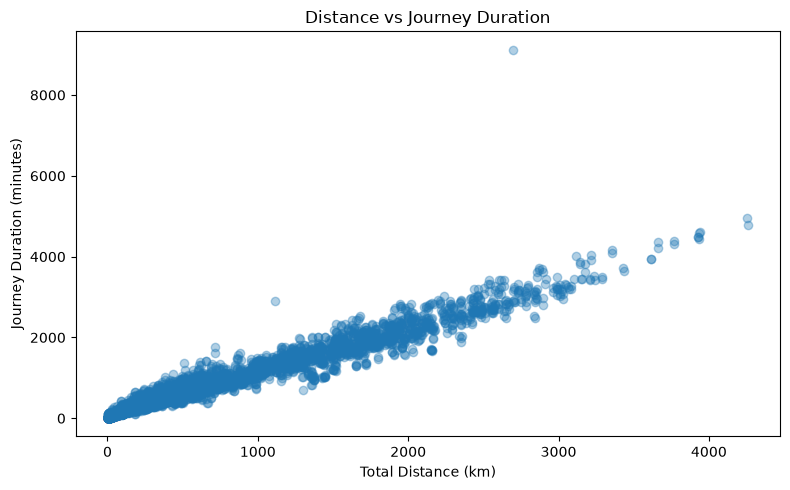

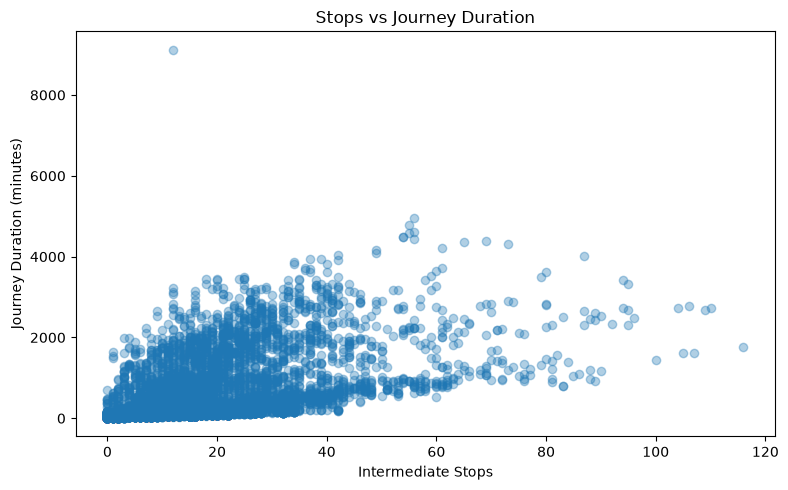

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df.Total_Distance, df[TARGET], alpha=0.35)
plt.xlabel('Total Distance (km)'); plt.ylabel('Journey Duration (minutes)')
plt.title('Distance vs Journey Duration'); plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df.Number_of_Stops, df[TARGET], alpha=0.35)
plt.xlabel('Intermediate Stops'); plt.ylabel('Journey Duration (minutes)')
plt.title('Stops vs Journey Duration'); plt.tight_layout(); plt.show()


,Train_No,Total_Distance,Total_Stations,Number_of_Stops,Departure_Minutes,Arrival_Minutes,Journey_Duration_Minutes,Journey_Duration_Hours
Train_No,1.000000,-0.537528,-0.317849,-0.317849,-0.063535,0.108939,-0.530571,-0.530582
Total_Distance,-0.537528,1.000000,0.462398,0.462398,0.078553,-0.099046,0.982010,0.982010
Total_Stations,-0.317849,0.462398,1.000000,1.000000,-0.047578,-0.015143,0.544013,0.544016
Number_of_Stops,-0.317849,0.462398,1.000000,1.000000,-0.047578,-0.015143,0.544013,0.544016
Departure_Minutes,-0.063535,0.078553,-0.047578,-0.047578,1.000000,0.430078,0.067349,0.067353
Arrival_Minutes,0.108939,-0.099046,-0.015143,-0.015143,0.430078,1.000000,-0.097166,-0.097161
Journey_Duration_Minutes,-0.530571,0.982010,0.544013,0.544013,0.067349,-0.097166,1.000000,1.000000
Journey_Duration_Hours,-0.530582,0.982010,0.544016,0.544016,0.067353,-0.097161,1.000000,1.000000


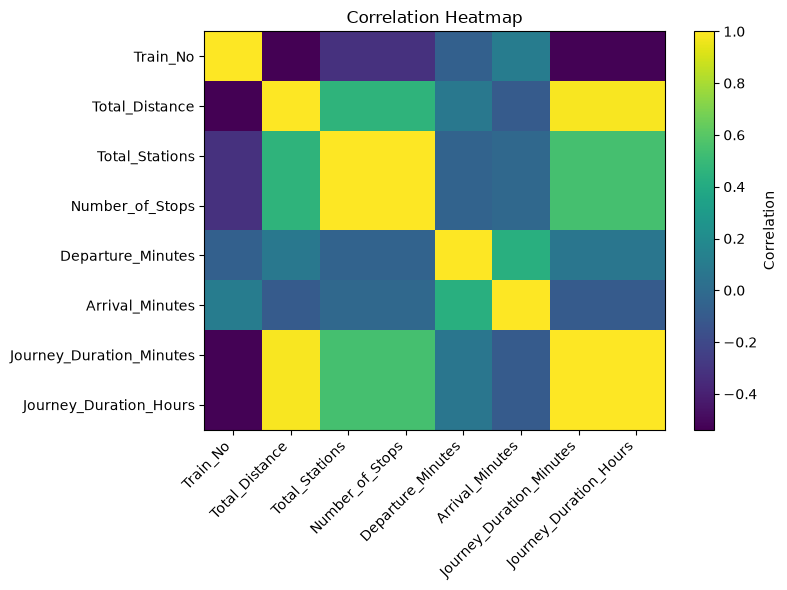

,count,mean,median
,Journey_Duration_Minutes,Journey_Duration_Minutes,Journey_Duration_Minutes
Number_of_Stops,,,
0,1249,52.31,48.0
1,382,77.97,45.0
2,272,85.51,32.5
3,250,158.15,55.0
4,249,179.25,75.0
...,...,...,...
106,1,2790.00,2790.0
107,1,1610.00,1610.0


In [5]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr(numeric_only=True)
display(corr)
plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Heatmap'); plt.tight_layout(); plt.show()

pivot = pd.pivot_table(df, values=TARGET, index='Number_of_Stops', aggfunc=['count', 'mean', 'median']).round(2)
display(pivot)
pivot.to_csv(OUTPUT_DIR / 'notebook_level3_stops_summary.csv')


## Level 4 — Train and evaluate Linear Regression


,Model,MAE,RMSE,R2
0,Multiple Linear Regression,58.5568,157.4458,0.9454


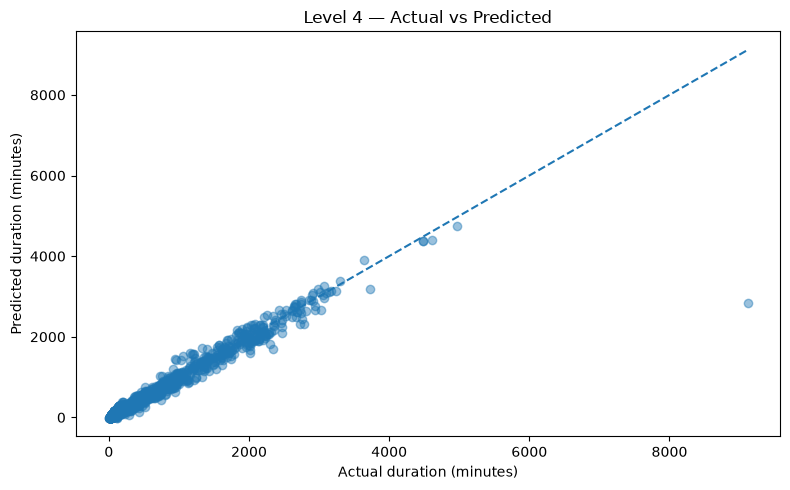

In [6]:
X = df[FEATURES_IMPROVED]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
level4_metrics = pd.DataFrame([{
    'Model': 'Multiple Linear Regression',
    'MAE': mean_absolute_error(y_test, linear_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, linear_pred)),
    'R2': r2_score(y_test, linear_pred),
}])
display(level4_metrics.round(4))
plt.figure(figsize=(8, 5)); plt.scatter(y_test, linear_pred, alpha=0.45)
lo, hi = min(y_test.min(), linear_pred.min()), max(y_test.max(), linear_pred.max())
plt.plot([lo, hi], [lo, hi], '--')
plt.xlabel('Actual duration (minutes)'); plt.ylabel('Predicted duration (minutes)')
plt.title('Level 4 — Actual vs Predicted'); plt.tight_layout(); plt.show()



## Level 5 — Compare models


,Model,MAE,RMSE,R2
0,Random Forest,35.0940,150.4686,0.9501
1,Multiple Linear Regression,58.5568,157.4458,0.9454
2,Basic Linear Regression,67.4139,167.3811,0.9383


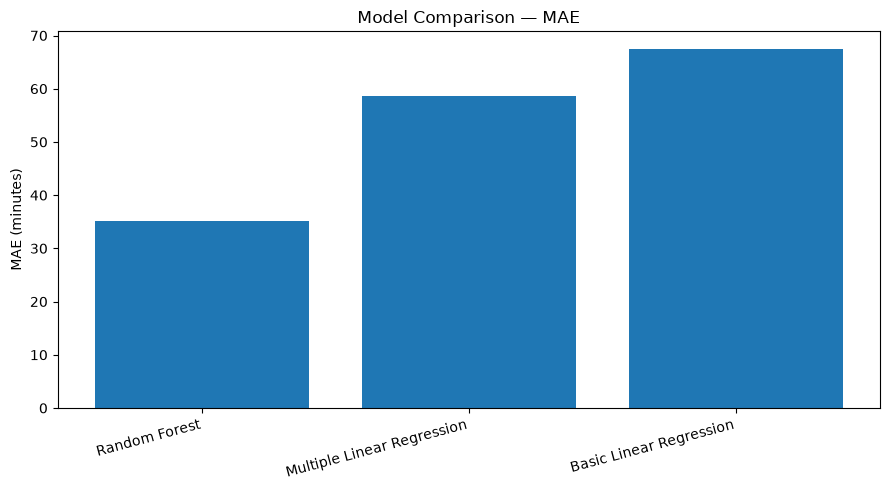

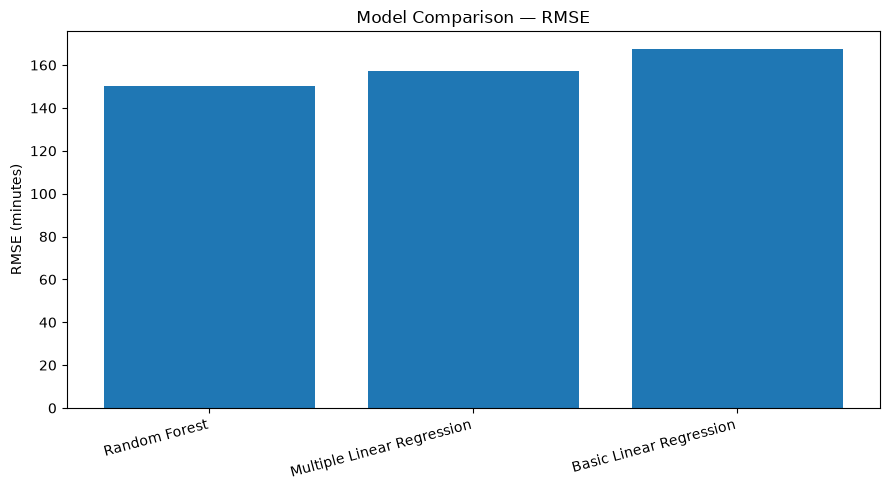

In [7]:
model_specs = {
    'Basic Linear Regression': {'model': LinearRegression(), 'features': FEATURES_BASIC},
    'Multiple Linear Regression': {'model': LinearRegression(), 'features': FEATURES_IMPROVED},
    'Random Forest': {'model': RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=2, random_state=42, n_jobs=-1), 'features': FEATURES_IMPROVED},
}
comparison_rows, predictions, trained_models = [], {}, {}
for name, spec in model_specs.items():
    feats, estimator = spec['features'], spec['model']
    estimator.fit(X_train[feats], y_train)
    pred = estimator.predict(X_test[feats])
    trained_models[name] = estimator
    predictions[name] = pred
    comparison_rows.append({'Model': name, 'MAE': mean_absolute_error(y_test, pred), 'RMSE': np.sqrt(mean_squared_error(y_test, pred)), 'R2': r2_score(y_test, pred)})
comparison_df = pd.DataFrame(comparison_rows).sort_values('MAE').reset_index(drop=True)
display(comparison_df.round(4))

plt.figure(figsize=(9, 5)); plt.bar(comparison_df.Model, comparison_df.MAE)
plt.ylabel('MAE (minutes)'); plt.title('Model Comparison — MAE')
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()
plt.figure(figsize=(9, 5)); plt.bar(comparison_df.Model, comparison_df.RMSE)
plt.ylabel('RMSE (minutes)'); plt.title('Model Comparison — RMSE')
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()


In [9]:
best_model_name = comparison_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_features = model_specs[best_model_name]['features']
print('Selected by lowest test MAE:', best_model_name)

model_package = {
    'model': best_model,
    'features': best_features,
    'target': TARGET,
    'model_name': best_model_name,
    'metrics': {row['Model']: {'MAE': float(row['MAE']), 'RMSE': float(row['RMSE']), 'R2': float(row['R2'])} for _, row in comparison_df.iterrows()},
}
joblib.dump(model_package, MODEL_DIR / 'best_model.pkl')
comparison_df.to_csv(OUTPUT_DIR / 'level5_model_comparison.csv', index=False)

prediction_df = X_test.copy()
prediction_df['Actual_Duration_Minutes'] = y_test.to_numpy()
for name, pred in predictions.items():
    prediction_df[name.lower().replace(' ', '_') + '_prediction'] = pred
prediction_df.to_csv(OUTPUT_DIR / 'level5_predictions.csv', index=False)
print('Saved model, comparison, and test predictions.')


Selected by lowest test MAE: Random Forest
Saved model, comparison, and test predictions.


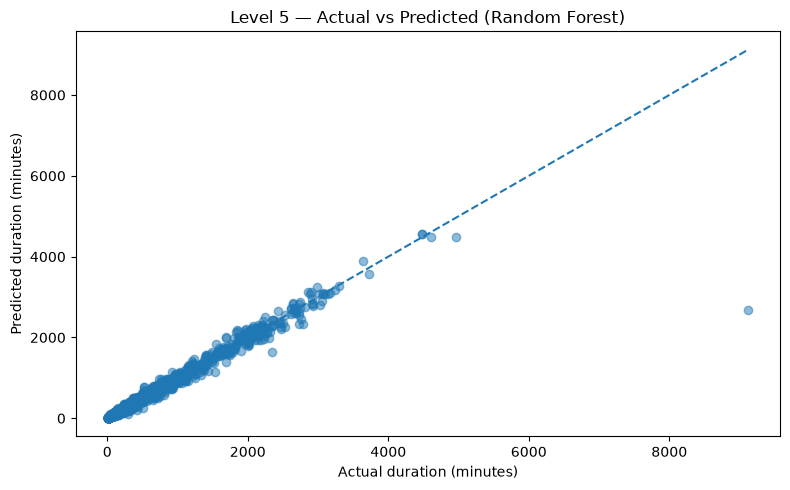

In [10]:
best_pred = predictions[best_model_name]
plt.figure(figsize=(8, 5)); plt.scatter(y_test, best_pred, alpha=0.5)
lo, hi = min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())
plt.plot([lo, hi], [lo, hi], '--')
plt.xlabel('Actual duration (minutes)'); plt.ylabel('Predicted duration (minutes)')
plt.title(f'Level 5 — Actual vs Predicted ({best_model_name})')
plt.tight_layout(); plt.show()


## Interpretation and limitations

- **MAE:** average absolute error in minutes; lower is better.
- **RMSE:** penalizes larger errors more strongly; lower is better.
- **R²:** explained variation on this test split; it is not the percentage of predictions that are correct.
- Model selection uses test-set MAE, so report these as comparison results on this split, not an independent final evaluation.
- The target is reconstructed scheduled journey duration, not live running time or delay prediction.
- Inspect unusually long durations and large residuals for possible data-quality issues.

## Level 6
Run the Streamlit app from the project root with `streamlit run app.py`.
